In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install rasterio

In [ ]:
pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.9 MB/s eta 0:00:00


In [ ]:
import os
import glob
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

Kmeans

In [ ]:
import rasterio
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/"

bands_paths = {
    'B4': base_path + 'T30UYC_20220630T110629_B04_10m.jp2',
    'B3': base_path + 'T30UYC_20220630T110629_B03_10m.jp2',
    'B2': base_path + 'T30UYC_20220630T110629_B02_10m.jp2'
}

band_data = []

for band in ['B4']:
    with rasterio.open(bands_paths[band]) as src:
        band_data.append(src.read(1))

band_stack = np.dstack(band_data)
valid_data_mask = np.all(band_stack > 0, axis=2)

X = band_stack[valid_data_mask].reshape((-1, 1))

kmeans = KMeans(n_clusters=2, random_state=0, n_init=10).fit(X)
labels = kmeans.labels_

labels_image = np.full(band_stack.shape[:2], -1, dtype=int)
labels_image[valid_data_mask] = labels

plt.figure(figsize=(8, 8))
plt.imshow(labels_image, cmap='viridis')
plt.title('K-means clustering on Sentinel-2 B04')
plt.colorbar(label='Cluster Label')
plt.axis('off')
plt.show()

del kmeans, labels, band_data, band_stack, valid_data_mask, X, labels_image

KeyboardInterrupt: 

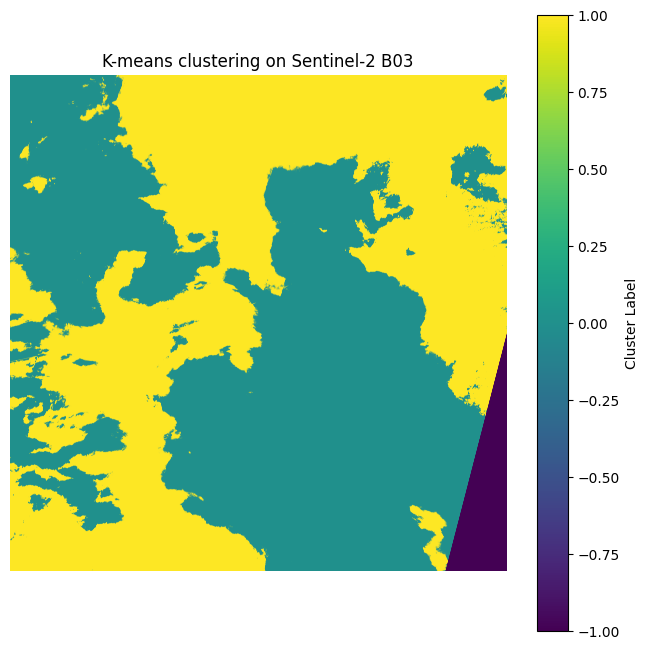

In [ ]:
import rasterio
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/"

bands_paths = {
    'B4': base_path + 'T30UYC_20220630T110629_B04_10m.jp2',
    'B3': base_path + 'T30UYC_20220630T110629_B03_10m.jp2',
    'B2': base_path + 'T30UYC_20220630T110629_B02_10m.jp2'
}

band_data = []

for band in ['B3']:
    with rasterio.open(bands_paths[band]) as src:
        band_data.append(src.read(1))

band_stack = np.dstack(band_data)
valid_data_mask = np.all(band_stack > 0, axis=2)

X = band_stack[valid_data_mask].reshape((-1, 1))

kmeans = KMeans(n_clusters=2, random_state=0, n_init=10).fit(X)
labels = kmeans.labels_

labels_image = np.full(band_stack.shape[:2], -1, dtype=int)
labels_image[valid_data_mask] = labels

plt.figure(figsize=(8, 8))
plt.imshow(labels_image, cmap='viridis')
plt.title('K-means clustering on Sentinel-2 B03')
plt.colorbar(label='Cluster Label')
plt.axis('off')
plt.show()

del kmeans, labels, band_data, band_stack, valid_data_mask, X, labels_image

In [ ]:
import rasterio
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/"

bands_paths = {
    "B4": base_path + "T30UYC_20220630T110629_B04_10m.jp2",
    "B3": base_path + "T30UYC_20220630T110629_B03_10m.jp2",
    "B2": base_path + "T30UYC_20220630T110629_B02_10m.jp2"
}

print(bands_paths)

{'B4': '/content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/T30UYC_20220630T110629_B04_10m.jp2', 'B3': '/content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/T30UYC_20220630T110629_B03_10m.jp2', 'B2': '/content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/T30UYC_20220630T110629_B02_10m.jp2'}


In [ ]:
import os

for band, path in bands_paths.items():
    print(band, os.path.exists(path), path)

B4 True /content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/T30UYC_20220630T110629_B04_10m.jp2
B3 True /content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/T30UYC_20220630T110629_B03_10m.jp2
B2 True /content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/T30UYC_20220630T110629_B02_10m.jp2


B4 True /content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/T30UYC_20220630T110629_B04_10m.jp2
B3 True /content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/T30UYC_20220630T110629_B03_10m.jp2
B2 True /content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/T30UYC_20220630T110629_B02_10m.jp2


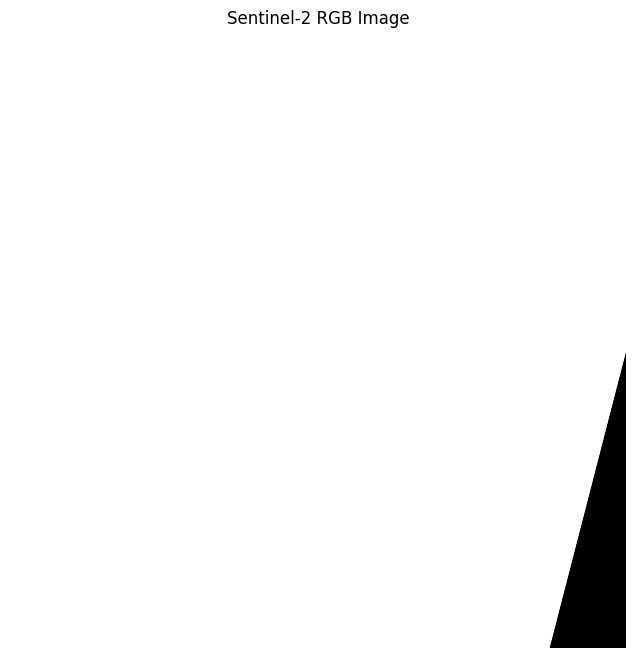

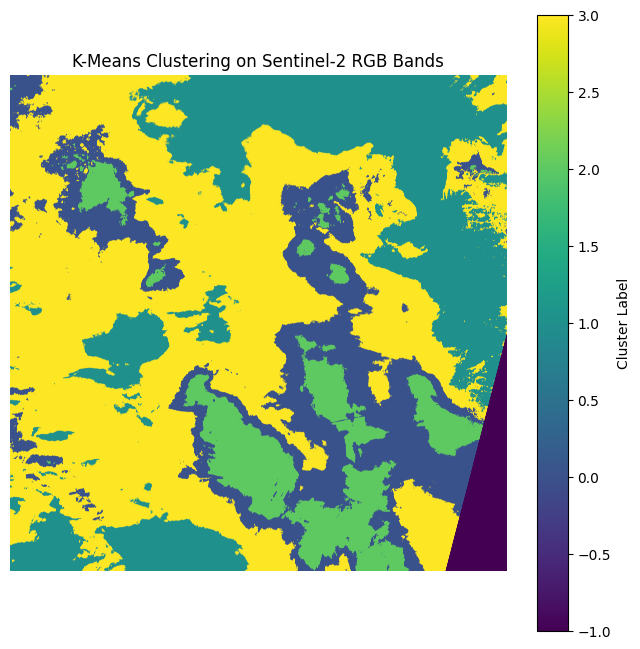

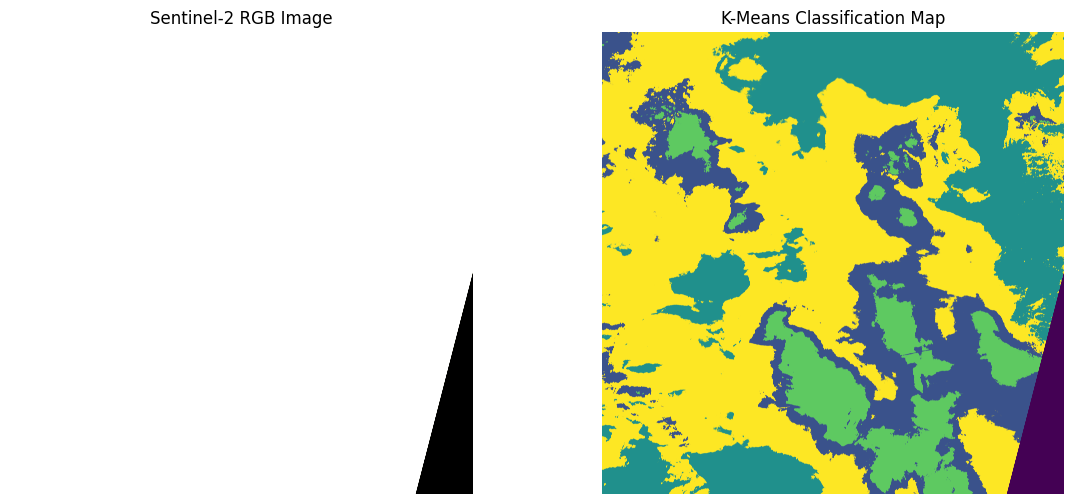

In [ ]:
import rasterio
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import os

base_path = "/content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/"

bands_paths = {
    "B4": base_path + "T30UYC_20220630T110629_B04_10m.jp2",
    "B3": base_path + "T30UYC_20220630T110629_B03_10m.jp2",
    "B2": base_path + "T30UYC_20220630T110629_B02_10m.jp2"
}

for band, path in bands_paths.items():
    print(band, os.path.exists(path), path)

band_data = []

for band in ["B4", "B3", "B2"]:
    with rasterio.open(bands_paths[band]) as src:
        band_data.append(src.read(1).astype("float32"))

band_stack = np.dstack(band_data)

rgb_display = np.clip(band_stack / 3000, 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(rgb_display)
plt.title("Sentinel-2 RGB Image")
plt.axis("off")
plt.show()

valid_data_mask = np.all(band_stack > 0, axis=2)

X = band_stack[valid_data_mask].reshape((-1, 3))
X = X / 10000.0

kmeans = KMeans(n_clusters=4, random_state=0, n_init=10).fit(X)
labels = kmeans.labels_

labels_image = np.full(band_stack.shape[:2], -1, dtype=int)
labels_image[valid_data_mask] = labels

plt.figure(figsize=(8, 8))
plt.imshow(labels_image, cmap="viridis")
plt.title("K-Means Clustering on Sentinel-2 RGB Bands")
plt.colorbar(label="Cluster Label")
plt.axis("off")
plt.show()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_display)
plt.title("Sentinel-2 RGB Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(labels_image, cmap="viridis")
plt.title("K-Means Classification Map")
plt.axis("off")

plt.show()

B4 True /content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/T30UYC_20220630T110629_B04_10m.jp2
B3 True /content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/T30UYC_20220630T110629_B03_10m.jp2
B2 True /content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/T30UYC_20220630T110629_B02_10m.jp2
Band stack shape: (10980, 10980, 3)


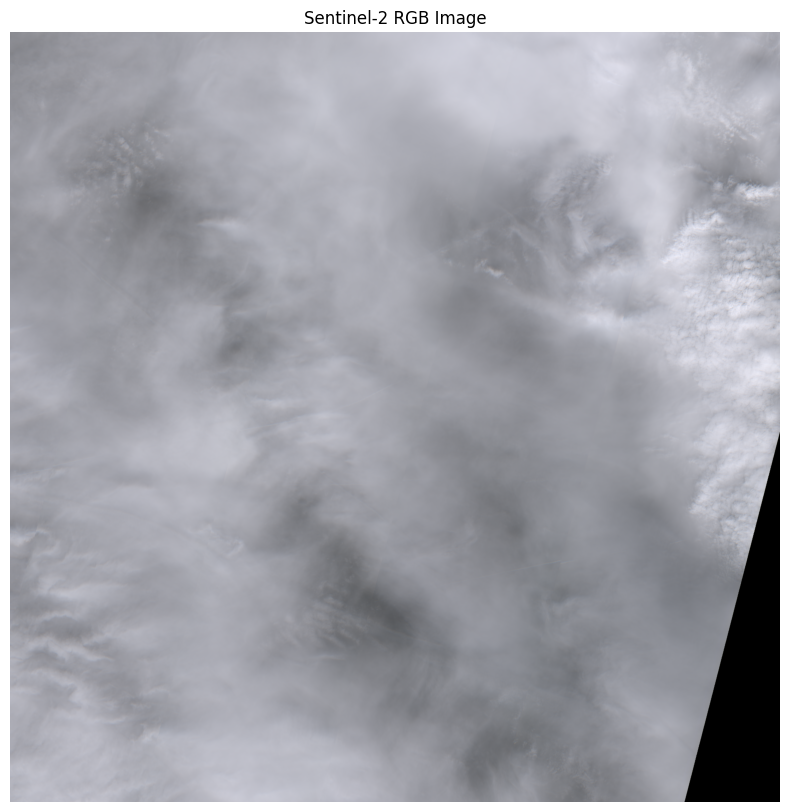

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

# Path to your R10m folder
base_path = "/content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/"

# RGB band paths
bands_paths = {
    "B4": base_path + "T30UYC_20220630T110629_B04_10m.jp2",  # Red
    "B3": base_path + "T30UYC_20220630T110629_B03_10m.jp2",  # Green
    "B2": base_path + "T30UYC_20220630T110629_B02_10m.jp2"   # Blue
}

# Check files exist
for band, path in bands_paths.items():
    print(band, os.path.exists(path), path)

# Read RGB bands
band_data = []

for band in ["B4", "B3", "B2"]:
    with rasterio.open(bands_paths[band]) as src:
        band_data.append(src.read(1).astype("float32"))

# Stack RGB bands
band_stack = np.dstack(band_data)

print("Band stack shape:", band_stack.shape)

# Automatic normalisation
rgb_display = band_stack.copy()

rgb_display = rgb_display - rgb_display.min()
rgb_display = rgb_display / rgb_display.max()

# Plot RGB image
plt.figure(figsize=(10, 10))
plt.imshow(rgb_display)
plt.title("Sentinel-2 RGB Image")
plt.axis("off")
plt.show()

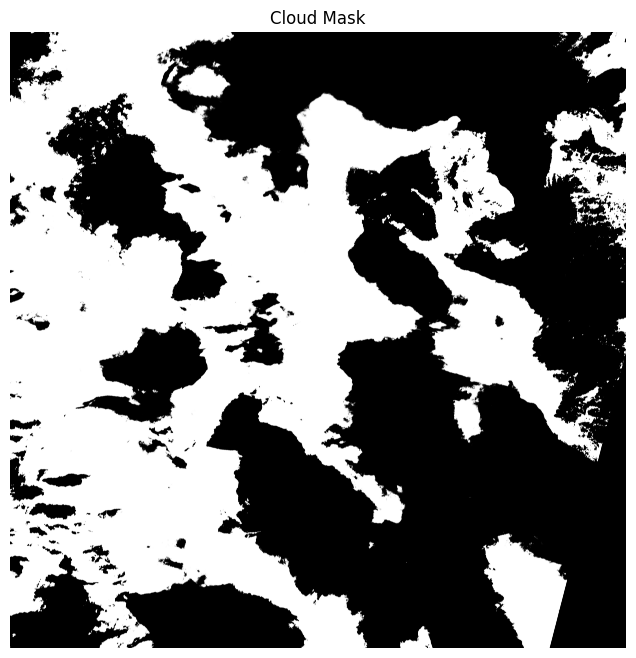

In [ ]:
cloud_cluster = 3

cloud_mask = labels_image == cloud_cluster

plt.figure(figsize=(8,8))
plt.imshow(cloud_mask, cmap="gray")
plt.title("Cloud Mask")
plt.axis("off")
plt.show()

B4 True /content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/T30UYC_20220630T110629_B04_10m.jp2
B3 True /content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/T30UYC_20220630T110629_B03_10m.jp2
B2 True /content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/T30UYC_20220630T110629_B02_10m.jp2


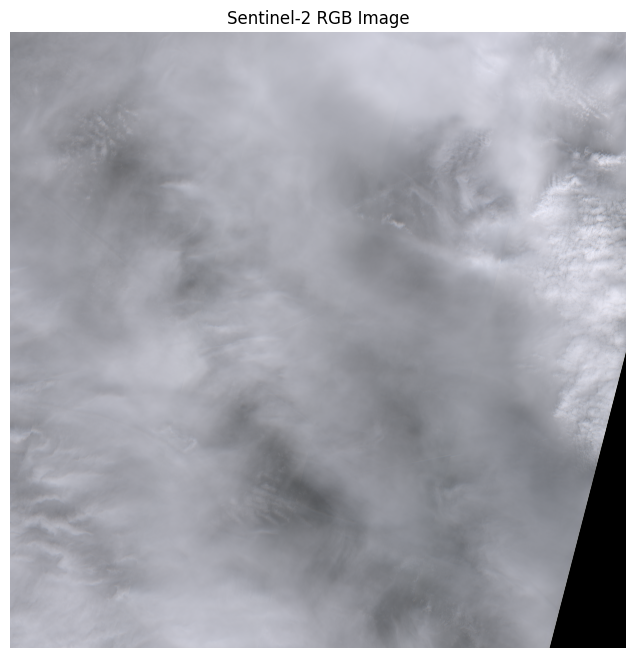

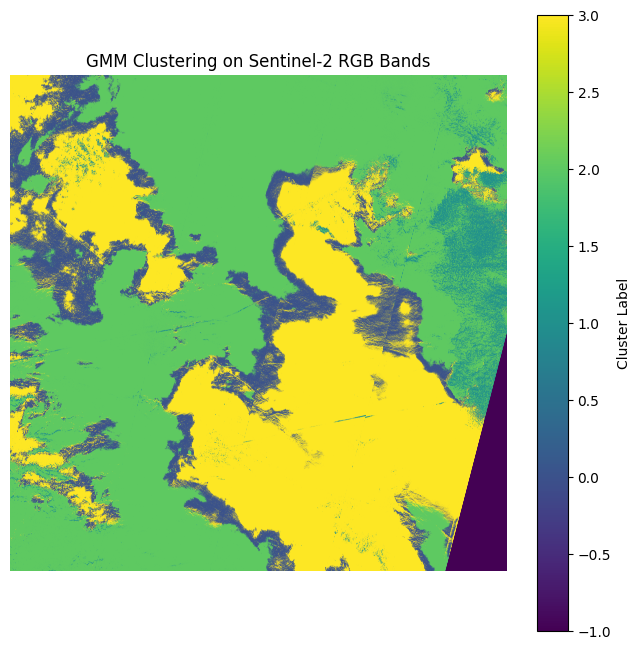

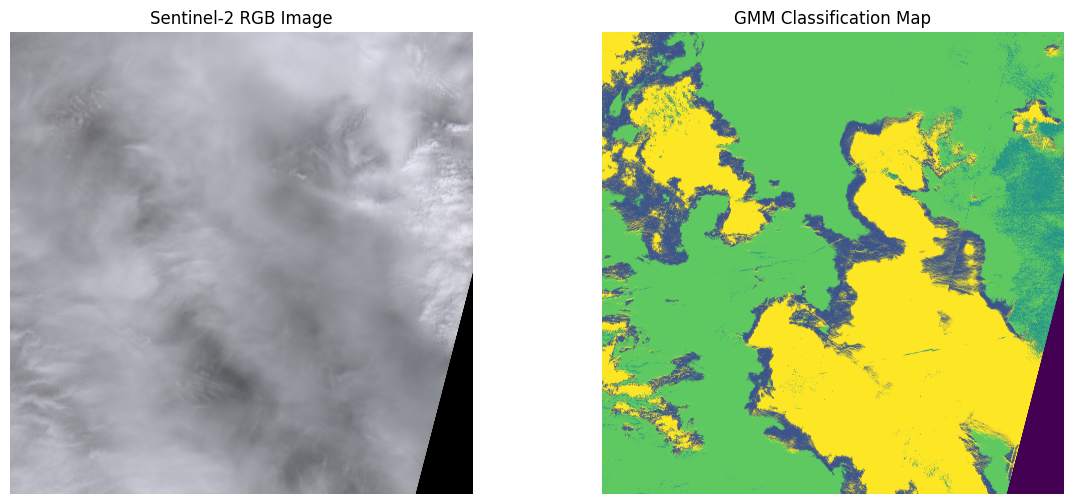

In [ ]:
import rasterio
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import os

# Path to your R10m folder
base_path = "/content/drive/MyDrive/cloud/4/S2B_MSIL2A_20220630T110629_N0510_R137_T30UYC_20240629T122536.SAFE/GRANULE/L2A_T30UYC_A027762_20220630T110828/IMG_DATA/R10m/"

bands_paths = {
    "B4": base_path + "T30UYC_20220630T110629_B04_10m.jp2",  # Red
    "B3": base_path + "T30UYC_20220630T110629_B03_10m.jp2",  # Green
    "B2": base_path + "T30UYC_20220630T110629_B02_10m.jp2"   # Blue
}

# Check files exist
for band, path in bands_paths.items():
    print(band, os.path.exists(path), path)

# Read and stack RGB bands
band_data = []

for band in ["B4", "B3", "B2"]:
    with rasterio.open(bands_paths[band]) as src:
        band_data.append(src.read(1).astype("float32"))

band_stack = np.dstack(band_data)

# Show RGB image
rgb_display = band_stack.copy()
rgb_display = rgb_display - rgb_display.min()
rgb_display = rgb_display / rgb_display.max()

plt.figure(figsize=(8, 8))
plt.imshow(rgb_display)
plt.title("Sentinel-2 RGB Image")
plt.axis("off")
plt.show()

# Create valid data mask
valid_data_mask = np.all(band_stack > 0, axis=2)

# Reshape for GMM
X = band_stack[valid_data_mask].reshape((-1, 3))

# Normalise data
X = X / X.max()

# GMM clustering
gmm = GaussianMixture(
    n_components=4,
    random_state=0,
    covariance_type="full"
)

labels = gmm.fit_predict(X)

# Create classification image
labels_image = np.full(band_stack.shape[:2], -1, dtype=int)
labels_image[valid_data_mask] = labels

# Plot GMM result
plt.figure(figsize=(8, 8))
plt.imshow(labels_image, cmap="viridis")
plt.title("GMM Clustering on Sentinel-2 RGB Bands")
plt.colorbar(label="Cluster Label")
plt.axis("off")
plt.show()

# Compare RGB and GMM result
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_display)
plt.title("Sentinel-2 RGB Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(labels_image, cmap="viridis")
plt.title("GMM Classification Map")
plt.axis("off")

plt.show()

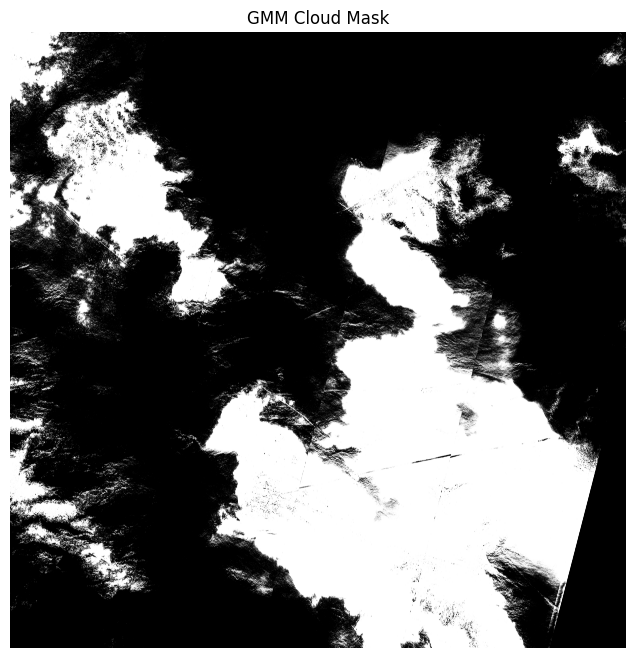

In [ ]:
# Select cloud cluster
cloud_cluster = 3

# Create cloud mask
cloud_mask = labels_image == cloud_cluster

# Plot black-and-white cloud mask
plt.figure(figsize=(8,8))
plt.imshow(cloud_mask, cmap="gray")
plt.title("GMM Cloud Mask")
plt.axis("off")
plt.show()

In [ ]:
# ==========================================
# CLOUD PIXEL STATISTICS
# ==========================================

import numpy as np

# KMeans statistics
kmeans_cloud_pixels = np.sum(kmeans_cloud_mask)

kmeans_total_pixels = kmeans_cloud_mask.size

kmeans_cloud_percentage = (
    kmeans_cloud_pixels / kmeans_total_pixels
) * 100

# GMM statistics
gmm_cloud_pixels = np.sum(gmm_cloud_mask)

gmm_total_pixels = gmm_cloud_mask.size

gmm_cloud_percentage = (
    gmm_cloud_pixels / gmm_total_pixels
) * 100

# ==========================================
# PRINT RESULTS
# ==========================================

print("========== CLOUD STATISTICS ==========\n")

print("K-MEANS")
print("Cloud pixels:", kmeans_cloud_pixels)
print("Total pixels:", kmeans_total_pixels)
print("Cloud coverage percentage: {:.2f}%".format(
    kmeans_cloud_percentage
))

print("\n-----------------------------------\n")

print("GMM")
print("Cloud pixels:", gmm_cloud_pixels)
print("Total pixels:", gmm_total_pixels)
print("Cloud coverage percentage: {:.2f}%".format(
    gmm_cloud_percentage
))

print("\n-----------------------------------\n")

print(
    "Difference in cloud pixels (GMM - KMeans):",
    gmm_cloud_pixels - kmeans_cloud_pixels
)

NameError: name 'kmeans_cloud_mask' is not defined